In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [3]:
#loading the csv file data to a panda dataframe
gold_data=pd.read_csv('gld_price_data.csv')

In [4]:
#print first five data from the dataframe
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [11]:
#to determine rows and columns present in the dataset
gold_data.shape

(2290, 6)

In [10]:
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [12]:
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [14]:
#getting the statistical measures of the data
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [15]:
#checking the number of missing values
gold_data.isnull().sum()


Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [17]:
#correlation
correlation = gold_data.corr(numeric_only=True)  # Calculate correlation only for numeric columns


<Axes: >

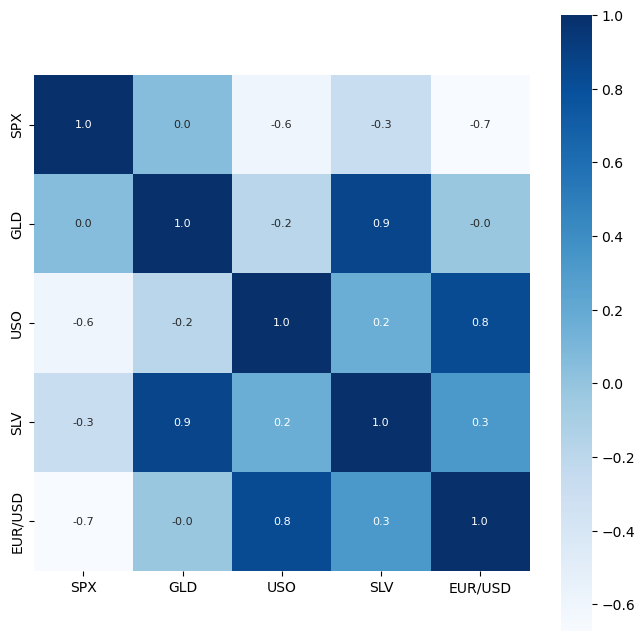

In [21]:
#constructing the heatmap to understand the correlation
plt.figure(figsize=(8, 8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size': 8}, cmap='Blues')


In [22]:
#correlation values of GLD
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


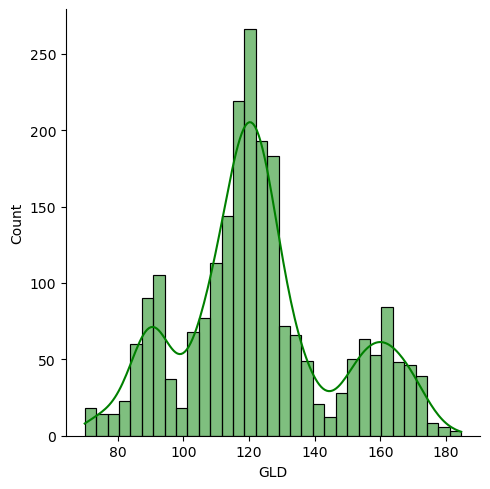

In [24]:
#checking the destribution of the gld prize
sns.displot(gold_data['GLD'], color='green', kde=True)


In [27]:
X=gold_data.drop(['Date','GLD'],axis=1)
Y=gold_data['GLD']

In [28]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [29]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


In [30]:
#spliting data into training data and test data
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [33]:
#training the model
reg=RandomForestRegressor(n_estimators=100)
reg.fit(X_train,Y_train)

RandomForestRegressor()

In [35]:
#prediction on test data
test_data_prediction=reg.predict(X_test)

In [36]:
print(test_data_prediction)

[168.61079931  81.90530005 116.19960017 127.66850043 120.54590187
 154.58369781 150.28969845 126.06560042 117.69069852 125.98780019
 116.51630067 172.19240082 141.47609835 167.72909848 115.16059975
 117.53820062 136.98950331 169.86550101 158.95190316 159.0130991
 154.98650046 125.42830012 175.84569969 156.75450259 125.27710066
  94.04909956  77.54190008 120.63429997 119.19019942 167.49029995
  88.22950079 125.35590039  91.1227005  117.62949997 121.03979953
 136.65200124 115.66250147 115.33980084 145.56339944 107.34530084
 103.88940207  87.01879769 126.57040054 117.8718     152.53039951
 119.73350006 108.32269995 108.29869871  93.10760043 127.17869771
  74.97870021 113.59619894 121.33200015 111.21699898 118.80669904
 120.89719893 159.5234994  166.20340106 147.23789702  85.87139872
  94.63970036  87.02619852  90.6993     118.95530082 126.3795012
 127.41349998 170.03829948 122.28749945 117.46029915  98.5365003
 168.37130163 143.47179772 131.98350276 121.20660191 121.66629916
 119.70870074

In [38]:
#R squareded error
error_score=metrics.r2_score(Y_test,test_data_prediction)
print("R squared error",error_score)

R squared error 0.9899315249480111


In [39]:
Y_test=list(Y_test)

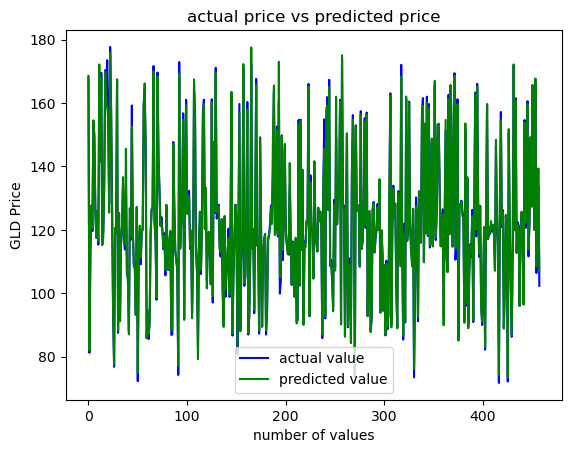

In [42]:
plt.plot(Y_test,color='blue',label='actual value')
plt.plot(test_data_prediction,color='green',label='predicted value')
plt.title('actual price vs predicted price')
plt.xlabel('number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()